### Trajectory analysis

In [37]:
import pandas as pd
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

import skmob
from skmob.preprocessing import compression, detection, clustering

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)
import warnings
warnings.simplefilter("ignore")

### read data, clean dat, adding auxiliary columns
 - use local time zone

In [38]:
events = pd.read_csv("GalapagostortoiseMovementEcology Programme_2009_2018.csv", sep=',', parse_dates=[2])
new_cols = pd.Series(events.columns.values).str.replace(pat = r"[-:]", repl="_")
tortoise = events.set_axis(labels = new_cols, axis =1)
tortoise.drop(tortoise.index[tortoise["manually_marked_outlier"].notna()], inplace = True)
tortoise.drop(columns =["manually_marked_outlier"], inplace=True)
tortoise.drop(index = tortoise.index[tortoise.isna().any(axis=1)], inplace=True)
cols = ['event_id', 'timestamp', 'location_long', 'location_lat',
       'eobs_temperature', 'ground_speed', 'heading', 'height_above_ellipsoid',
       #'individual_taxon_canonical_name', 'tag_local_identifier',
       'individual_local_identifier']
tortoise = tortoise[cols].assign()
tortoise.insert(loc = 2, column = "timestamp_UTC",
    value = tortoise['timestamp'].apply(lambda x: x.tz_localize(tz='UTC'))
)
tortoise.insert(loc = 3, column = "timestamp_local", 
    value = tortoise["timestamp_UTC"].apply(lambda x: x.tz_convert(tz='US/Pacific'))
)

tortoise.sort_values(by = ["individual_local_identifier", "timestamp_local"], inplace=True)

tortoise.insert(loc = 4, column = "minute_diff", 
    value = tortoise.groupby(['individual_local_identifier'])["timestamp_local"].diff()\
        .apply(lambda x: x/np.timedelta64(1, 'm')).fillna(0).astype('int64')
)

tortoise['year'] = tortoise["timestamp_local"].dt.year
tortoise['month'] = tortoise["timestamp_local"].dt.month
tortoise['date'] = tortoise["timestamp_local"].dt.date

In [39]:
from skmob.tessellation import tilers
from skmob.preprocessing import filtering
tessellation = tilers.tiler.get("h3_tessellation", base_shape="isla santa cruz", meters=20)
tessellation["tile_lng"] = tessellation.geometry.centroid.x
tessellation["tile_lat"] = tessellation.geometry.centroid.y

### trajectory
 - get trajectory and various compression for all tortoises

In [40]:
tortoise_trajectory = skmob.TrajDataFrame(tortoise, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local', \
)
tortoise_trajectory_mapping = tortoise_trajectory.mapping(tessellation) # map trajectory into tessellation tiles
tortoise_tiled = tortoise_trajectory_mapping.merge(tessellation, on = "tile_ID") # join to get the tile coordinates
tortoise_tiled.drop(columns =["lat","lng"], inplace=True) # drop the original lat/lng so that we can create new trajectory
tortoise_tiled.sort_values(by = ["uid", "datetime"], inplace=True) # sort before making trajectory
tortoise_tiled_trajectory = skmob.TrajDataFrame(tortoise_tiled, latitude='tile_lat', longitude='tile_lng', \
    user_id='uid', datetime='datetime', \
)
tortoise_trajectory_compressed = compression.compress(tortoise_trajectory, spatial_radius_km=0.02) # compressed trajectory
tortoise_tiled_trajectory_compressed = compression.compress(tortoise_tiled_trajectory, spatial_radius_km=0.02) # compressed trajectory

 - filter out those for tortoise 'Alison' for ease of visualization while developing code

In [41]:
alison = tortoise[tortoise["individual_local_identifier"] == "Alison"]
alison_trajectory = tortoise_trajectory.query("uid == 'Alison'")
alison_trajectory_mapping = tortoise_trajectory_mapping.query("uid == 'Alison'")
alison_tiled_trajectory = tortoise_tiled_trajectory.query("uid == 'Alison'")
alison_trajectory_compressed = tortoise_trajectory_compressed.query("uid == 'Alison'")
alison_tiled_trajectory_compressed = tortoise_tiled_trajectory_compressed.query("uid == 'Alison'")
#alison.shape, alison_trajectory.shape, alison_trajectory_mapping.shape, alison_tiled_trajectory.shape, alison_trajectory_compressed.shape, alison_tiled_trajectory_compressed.shape

### prepare auxiliary data
 - set color for consistent visualization
 - set date ranges for slicing trajectories and events

In [42]:
color_list = ['#883399','#66c066', '#ff800c','#60ff78','#301e4b'] # purple, green, orange, lime, dark purple
color_list.extend(list(sns.color_palette('tab10').as_hex()))

month_date_str = '05-01' # adjust this date for analysis needs
start_year = 2010
end_year = 2019
year_list = range(start_year, end_year)
s_date = []
for i in range(start_year, end_year+1):
    s_date.append(pd.Timestamp(str(i)+'-' +month_date_str).tz_localize(tz = 'US/Pacific'))
e_date = s_date[1:]
s_date.pop()

Timestamp('2019-05-01 00:00:00-0700', tz='US/Pacific')

### plot trajectory, compressed trajectory, and tiled compressed trajectory

In [43]:
m = alison_trajectory.plot_trajectory(hex_color=color_list[0],weight=1, zoom=14, opacity = 0.9,
        #tiles = 'OpenStreetMap', 
    )
alison_trajectory_compressed.plot_trajectory(map_f = m, hex_color = color_list[1],weight = 1, opacity = 0.9)
alison_tiled_trajectory_compressed.plot_trajectory(map_f = m, hex_color = color_list[2], weight=1, opacity = 0.9)
m 

### plot compressed trajectory by slices of time

In [44]:
june_2013 = pd.Timestamp('2013-06-01',tz='US/Pacific')
dec_2013 = pd.Timestamp('2013-12-01',tz='US/Pacific')
june_2014 = pd.Timestamp('2014-06-01',tz='US/Pacific')
dec_2014 = pd.Timestamp('2014-12-01',tz='US/Pacific')
map_f =alison_trajectory_compressed.query("datetime >= @june_2013 and datetime < @dec_2013").plot_trajectory(start_end_markers=True, max_points = 50000, weight=1, opacity=0.9,hex_color='#883399') #purple
alison_trajectory_compressed.query("datetime >= @dec_2013 and datetime < @june_2014").plot_trajectory(map_f = map_f, start_end_markers=True, max_points = 50000, weight=1, opacity=0.9,hex_color='#66c066') #green
alison_trajectory_compressed.query("datetime >= @june_2014 and datetime < @dec_2014").plot_trajectory(map_f = map_f, start_end_markers=True, max_points = 50000, weight=1, opacity=0.9,hex_color='#ff800c') #orange
map_f

### plot trajectory sliced by year

In [45]:
map_f = alison_trajectory_compressed.query("year == 2014").plot_trajectory(start_end_markers=True, max_points = 50000, weight=1, opacity=0.9,hex_color= color_list[0])
alison_trajectory_compressed.query("year == 2015").plot_trajectory(map_f=map_f, start_end_markers=True, max_points = 50000, weight=1, opacity=0.9,hex_color=color_list[1])
alison_trajectory_compressed.query("year == 2016").plot_trajectory(map_f=map_f, start_end_markers=True, max_points = 50000, weight=1, opacity=0.9,hex_color=color_list[2])
map_f

In [46]:
map_f = alison_trajectory.query("year == 2012").plot_trajectory(zoom=14, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#883399')
alison_trajectory.query("year == 2013").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#66c066')
alison_trajectory.query("year == 2014").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#ff800c')
alison_trajectory.query("year == 2015").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#60ff78')
alison_trajectory.query("year == 2016").plot_trajectory(map_f=map_f, start_end_markers=False, max_points = 50000, weight=1, opacity=0.9,hex_color='#301e4b')
map_f


In [47]:
import folium
def plot_coordinates(df, col_lat = "location_lat", col_long = "location_long", color = '#883399', map_f = None):
    coordinates = list(zip(df[col_lat], df[col_long]))

    if map_f is None:
        map_f = folium.Map(location=coordinates[0], zoom_start=14)
    folium.PolyLine(coordinates, weight = 1, color = color).add_to(map_f)
    return map_f
m = plot_coordinates(alison, "location_lat", "location_long", color = color_list[0])
plot_coordinates(tortoise.iloc[100000:120000], color = color_list[1], map_f = m)


In [48]:
import folium
alison_coordinates = list(zip(alison.location_lat, alison.location_long))

m = folium.Map(location=alison_coordinates[0], zoom_start=14)
folium.PolyLine(alison_coordinates, tooltip="Alison",weight = 1).add_to(m)
m

In [49]:
k = 0
m = None
for i, j in zip(s_date,e_date):
    temp_df = alison[(alison["timestamp_local"] >= i) & (alison["timestamp_local"] < j)].assign()
    m = plot_coordinates(temp_df, col_lat = "location_lat", col_long = "location_long", color=color_list[k],map_f=m)
    k = k+1
m

### stay locaiton: minutes_for_a_stop = 400, 6.8 hours that the tortoise stayed in the stay location


In [54]:
tortoise_stay_location = detection.stay_locations(tortoise_trajectory, stop_radius_factor=0.02, minutes_for_a_stop=400,
    spatial_radius_km=0.2, leaving_time=True)
alison_stay_location = tortoise_stay_location.query("uid == 'Alison'")

In [55]:
alison_stay_segment = []
for i, j in zip(s_date,e_date):
    alison_stay_segment.append(alison_stay_location[(alison_stay_location["datetime"] >= i) & (alison_stay_location["datetime"] < j)])
    alison_segment = []
for i, j in zip(s_date,e_date):
    alison_segment.append(alison_trajectory[(alison_trajectory["datetime"] >= i) & (alison_trajectory["datetime"] < j)])

In [57]:
m = alison_segment[0].plot_trajectory(hex_color = color_list[0], zoom=14)
alison_segment[1].plot_trajectory(map_f = m,weight =1, opacity = 0.9, hex_color = color_list[1])
alison_segment[2].plot_trajectory(map_f = m, weight =1, opacity = 0.9,hex_color = color_list[2])
alison_segment[3].plot_trajectory(map_f = m, weight =1, opacity = 0.9,hex_color = color_list[3])
alison_segment[4].plot_trajectory(map_f = m, weight =1, opacity = 0.9,hex_color = color_list[4])
alison_segment[5].plot_trajectory(map_f = m, weight =1, opacity = 0.9,hex_color = color_list[5])
alison_segment[6].plot_trajectory(map_f = m, weight =1, opacity = 0.9,hex_color = color_list[6])
alison_segment[7].plot_trajectory(map_f = m, weight =1, opacity = 0.9,hex_color = color_list[7])
alison_stay_segment[0].plot_stops(map_f = m, radius = 5, hex_color = color_list[0])
alison_stay_segment[1].plot_stops(map_f = m, radius = 5, hex_color = color_list[1])
alison_stay_segment[2].plot_stops(map_f = m, radius = 5, hex_color = color_list[2])
alison_stay_segment[3].plot_stops(map_f = m, radius = 5, hex_color = color_list[3])
alison_stay_segment[4].plot_stops(map_f = m, radius = 5, hex_color = color_list[4])
alison_stay_segment[5].plot_stops(map_f = m, radius = 5, hex_color = color_list[5])
alison_stay_segment[6].plot_stops(map_f = m, radius = 5, hex_color = color_list[6])
alison_stay_segment[7].plot_stops(map_f = m, radius = 5, hex_color = color_list[7])
m

In [58]:
m = folium.Map(location=[-0.65, -90.35], zoom_start=12)
stay_coordinates = list(zip(alison_stay_location.lat, alison_stay_location.lng))

for i, j, k, year in zip(alison_stay_location.lat, alison_stay_location.lng, alison_stay_location.leaving_datetime, alison_stay_location.year):
    year = year -2011
    folium.CircleMarker(location=[i,j], tooltip = str(k), radius = 5, weight=1, color = color_list[year]).add_to(m)
folium.PolyLine(stay_coordinates, weight=1).add_to(m)
m


<Axes: xlabel='datetime'>

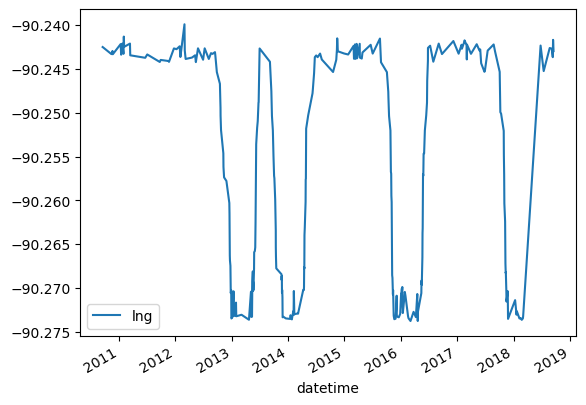

In [18]:
alison_stay_location.plot(x="datetime", y ="lng")

### run clustering on stay locations

In [72]:
tortoise_stay_clusters = clustering.cluster(tortoise_stay_location, cluster_radius_km=0.15, min_samples=1)
alison_stay_clusters = tortoise_stay_clusters.query("uid == 'Alison'")

In [70]:
m = alison_stay_clusters[alison_stay_clusters["cluster"] == 0].plot_stops(hex_color = color_list[0], zoom=14, radius = 5)
alison_stay_clusters[alison_stay_clusters["cluster"] == 1].plot_stops(map_f = m, hex_color = color_list[1], radius =5)
alison_stay_clusters[alison_stay_clusters["cluster"] == 2].plot_stops(map_f = m, hex_color = color_list[2], radius = 5)
m


### plot the diary of one individual

<Axes: title={'center': 'user Alison'}>

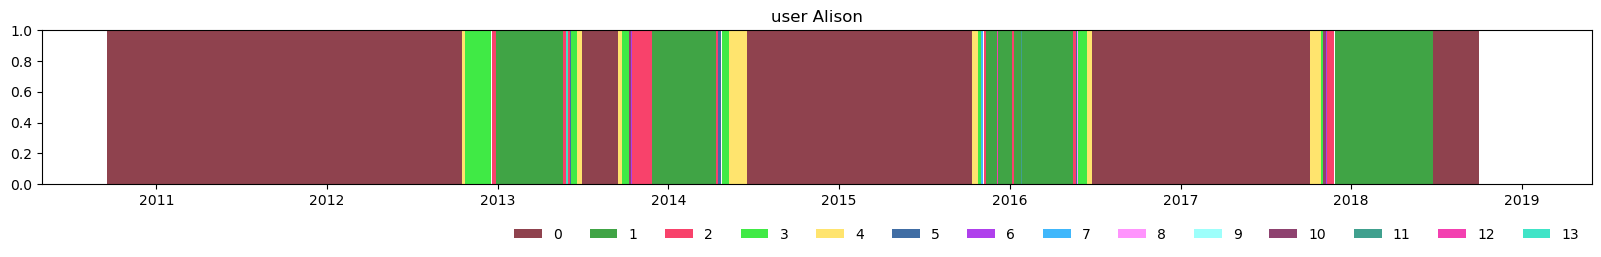

In [73]:
user = "Alison"
start_datetime = pd.to_datetime('2010-05-01 030000').tz_localize(tz='US/Pacific')
end_datetime = pd.to_datetime('2019-05-31 030000').tz_localize(tz='US/Pacific')
tortoise_stay_clusters.plot_diary(user, start_datetime=start_datetime, end_datetime=end_datetime,legend=True)

### distances between sliced stay location segments, time aligned

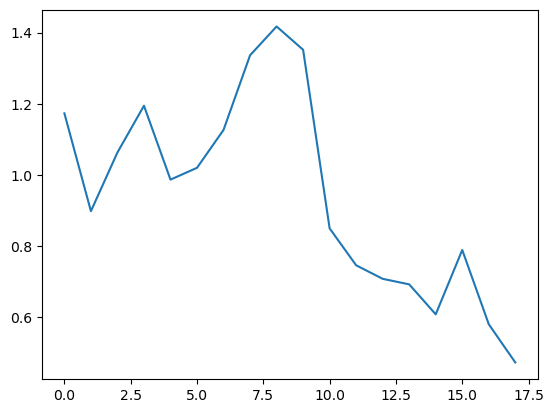

In [22]:
date_20121001 = pd.Timestamp('2012-10-01').tz_localize(tz = 'US/Pacific')
date_20121231 = pd.Timestamp('2012-12-31').tz_localize(tz = 'US/Pacific')
date_20131001 = pd.Timestamp('2013-10-01').tz_localize(tz = 'US/Pacific')
date_20131231 = pd.Timestamp('2013-12-31').tz_localize(tz = 'US/Pacific')
s1 = alison_stay_location[(alison_stay_location['datetime'] >= date_20121001) & (alison_stay_location['datetime'] <= date_20121231)]
s2 = alison_stay_location[(alison_stay_location['datetime'] >= date_20131001) & (alison_stay_location['datetime'] <= date_20131231)]
from geopy.distance import geodesic as GD
coordinates1 = list(zip(s1.lat, s1.lng))
coordinates2 = list(zip(s2.lat, s2.lng))
dist_list = []
for p1, p2 in zip(coordinates1, coordinates2):
    dist_list.append(GD(p1,p2).km)
plt.plot(dist_list)

### compute pairwise distances between trajectory segments sliced by time
 - follow the dark path to find better-matched alignment between two sequences
 - pairwise computation could take minutes to complete

<Axes: >

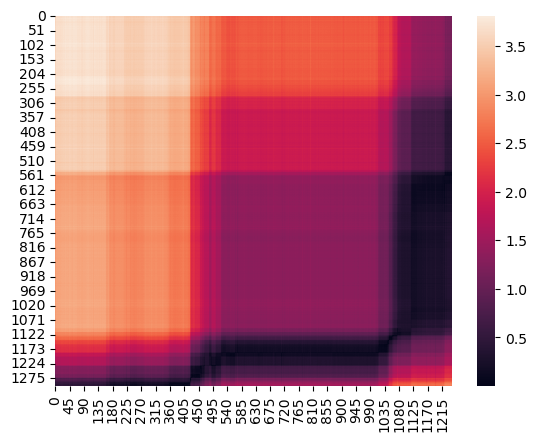

In [8]:
date_20121001 = pd.Timestamp('2012-10-01').tz_localize(tz = 'US/Pacific')
date_20121231 = pd.Timestamp('2012-12-31').tz_localize(tz = 'US/Pacific')
date_20131001 = pd.Timestamp('2013-10-01').tz_localize(tz = 'US/Pacific')
date_20131231 = pd.Timestamp('2013-12-31').tz_localize(tz = 'US/Pacific')
s1 = alison_trajectory[(alison_trajectory['datetime'] >= date_20121001) & (alison_trajectory['datetime'] <= date_20121231)]
s2 = alison_trajectory[(alison_trajectory['datetime'] >= date_20131001) & (alison_trajectory['datetime'] <= date_20131231)]
from geopy.distance import geodesic as GD
coordinates1 = list(zip(s1.lat, s1.lng))
coordinates2 = list(zip(s2.lat, s2.lng))
dist_list = []
for p1, p2 in zip(coordinates1, coordinates2):
    dist_list.append(GD(p1,p2).km)
row = []
matrix = []
for i in coordinates1:
    for j in coordinates2:
        row.append(round(GD(i,j).km, 4))
    matrix.append(row)
    row = []
sns.heatmap(np.flip(np.array(matrix),axis=1))

 - adjusting the starting time of second slice to see if it gives better alignment

In [1]:
# this below cell will take about 5 minutes to complete on my macbook
date_20121001 = pd.Timestamp('2012-10-01').tz_localize(tz = 'US/Pacific')
date_20121231 = pd.Timestamp('2012-12-31').tz_localize(tz = 'US/Pacific')
date_20131001 = pd.Timestamp('2013-09-01').tz_localize(tz = 'US/Pacific')
date_20131231 = pd.Timestamp('2013-12-31').tz_localize(tz = 'US/Pacific')
s1 = alison_trajectory[(alison_trajectory['datetime'] >= date_20121001) & (alison_trajectory['datetime'] <= date_20121231)]
s2 = alison_trajectory[(alison_trajectory['datetime'] >= date_20131001) & (alison_trajectory['datetime'] <= date_20131231)]
from geopy.distance import geodesic as GD
coordinates1 = list(zip(s1.lat, s1.lng))
coordinates2 = list(zip(s2.lat, s2.lng))
dist_list = []
for p1, p2 in zip(coordinates1, coordinates2):
    dist_list.append(GD(p1,p2).km)
row = []
matrix = []
for i in coordinates1:
    for j in coordinates2:
        row.append(round(GD(i,j).km, 4))
    matrix.append(row)
    row = []
sns.heatmap(np.flip(np.array(matrix),axis=1))


NameError: name 'pd' is not defined

 - the rise and fall of the dark region indicates two local optimal alignments
 - this could indicate two separate alignments within the same segment

<Axes: >

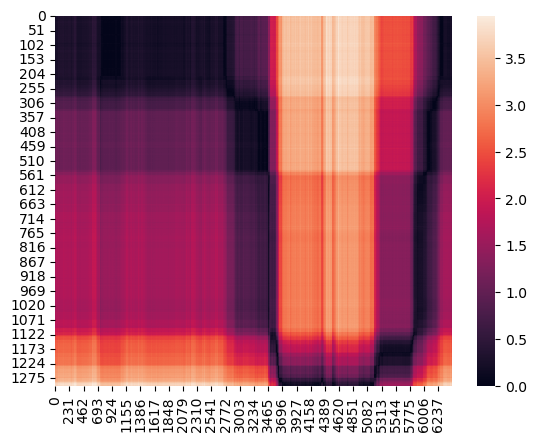

In [25]:
# this cell as is will take about 20 minutes to compute on my macBook, might take a long time for others
date_20121001 = pd.Timestamp('2012-10-01').tz_localize(tz = 'US/Pacific')
date_20121231 = pd.Timestamp('2012-12-31').tz_localize(tz = 'US/Pacific')
date_20131001 = pd.Timestamp('2013-09-01').tz_localize(tz = 'US/Pacific')
date_20131231 = pd.Timestamp('2014-12-31').tz_localize(tz = 'US/Pacific')
s1 = alison_trajectory[(alison_trajectory['datetime'] >= date_20121001) & (alison_trajectory['datetime'] <= date_20121231)]
s2 = alison_trajectory[(alison_trajectory['datetime'] >= date_20131001) & (alison_trajectory['datetime'] <= date_20131231)]
from geopy.distance import geodesic as GD
coordinates1 = list(zip(s1.lat, s1.lng))
coordinates2 = list(zip(s2.lat, s2.lng))
dist_list = []
for p1, p2 in zip(coordinates1, coordinates2):
    dist_list.append(GD(p1,p2).km)
row = []
matrix = []
for i in coordinates1:
    for j in coordinates2:
        row.append(round(GD(i,j).km, 4))
    matrix.append(row)
    row = []
#s1.shape, s2.shape, np.array(matrix).shape
sns.heatmap(np.flip(np.array(matrix),axis=1))

<Axes: xlabel='timestamp_local', ylabel='location_long'>

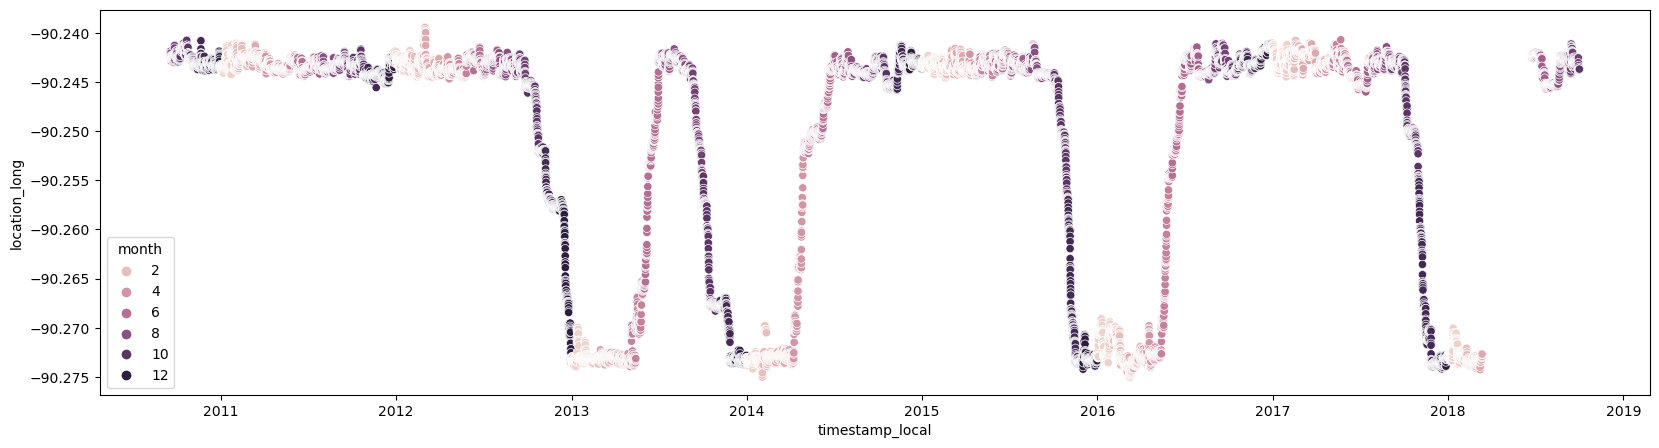

In [26]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <1") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="location_long", hue="month")

<Axes: xlabel='timestamp_local', ylabel='location_lat'>

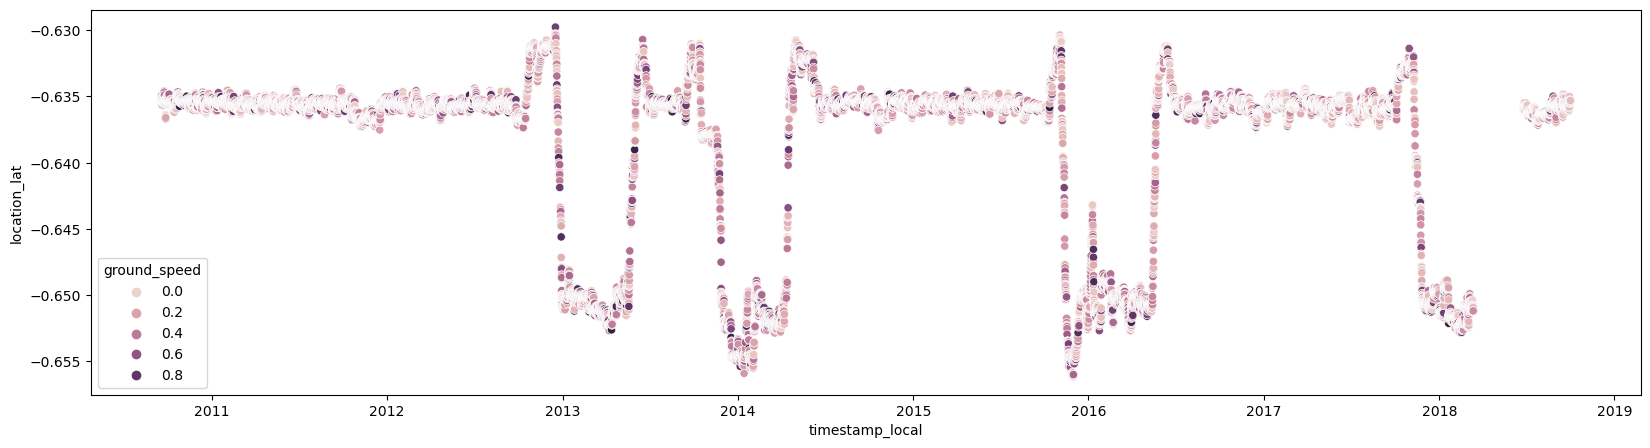

In [27]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <1") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="location_lat", hue="ground_speed")

<Axes: xlabel='timestamp_local', ylabel='ground_speed'>

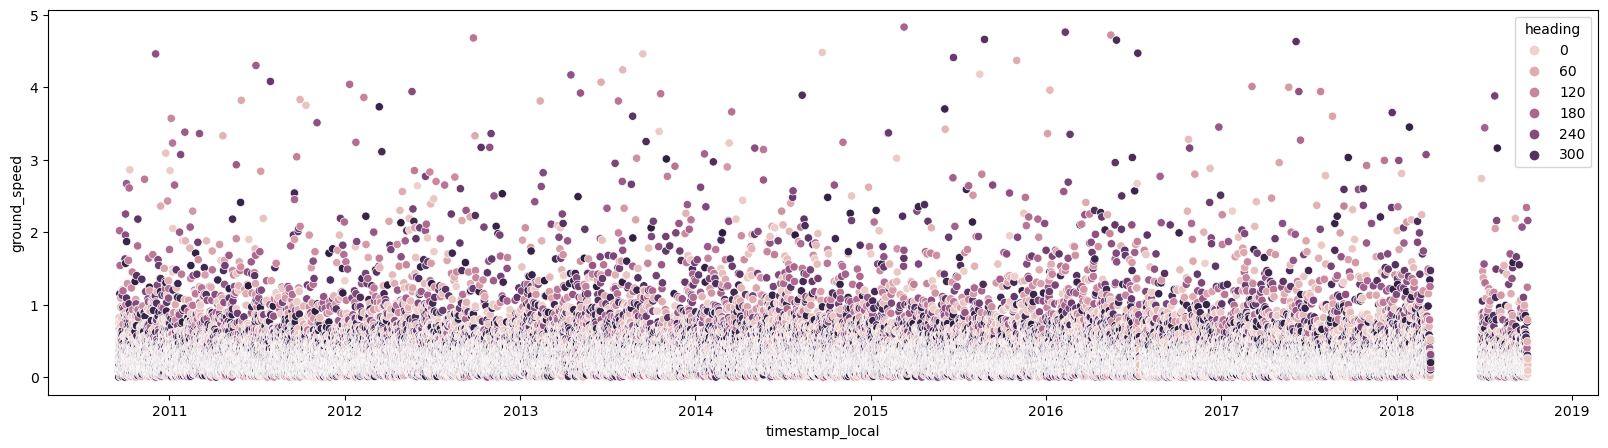

In [28]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <5") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="ground_speed", hue="heading")

<Axes: title={'center': 'user Christian'}>

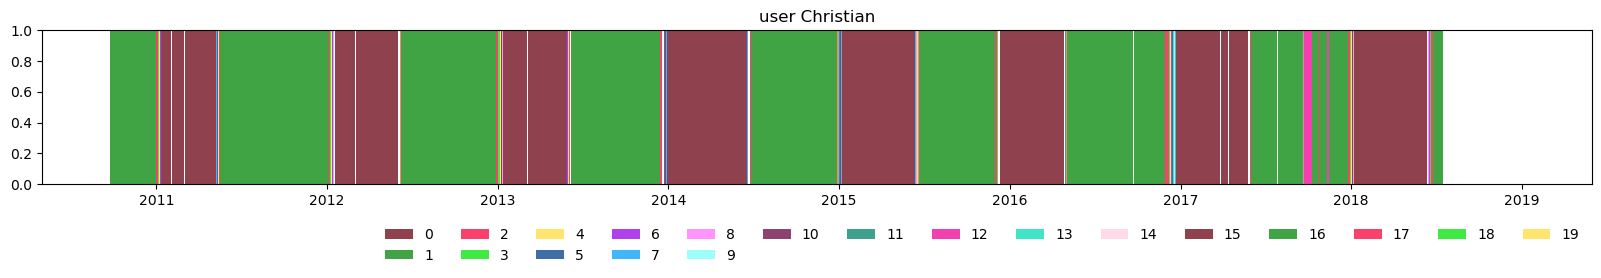

In [29]:
user = "Christian"
start_datetime = pd.to_datetime('2010-05-01 030000').tz_localize(tz='US/Pacific')
end_datetime = pd.to_datetime('2019-05-31 030000').tz_localize(tz='US/Pacific')
tortoise_stay_clusters.plot_diary(user, start_datetime=start_datetime, end_datetime=end_datetime,legend=True)

In [30]:
def plot_invidual_lat_long(name, lat_long):
    plt.figure(figsize = (20,5))
    df_name = tortoise[tortoise["individual_local_identifier"] == name]
    sns.scatterplot(df_name, x = "timestamp", y=lat_long)


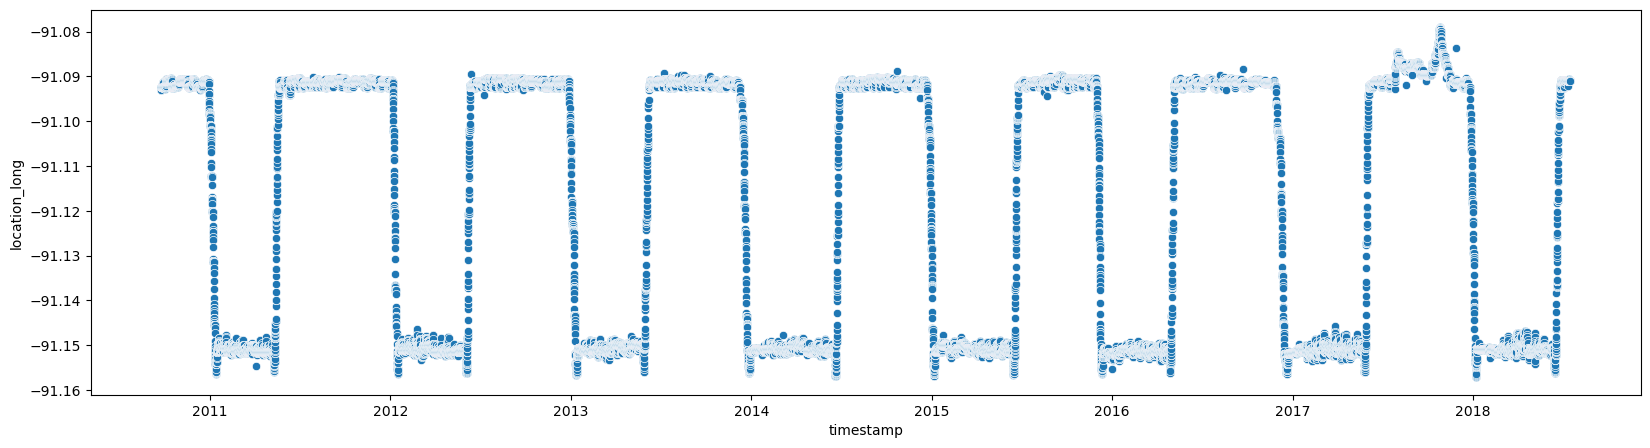

In [31]:
plot_invidual_lat_long("Christian", "location_long")

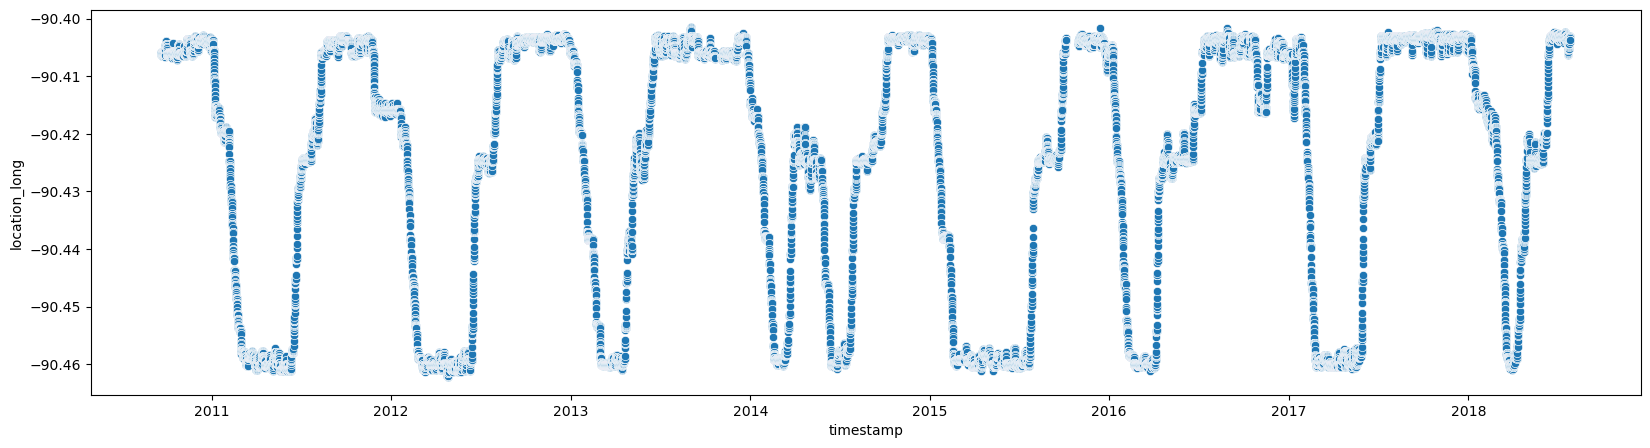

In [32]:
plot_invidual_lat_long("Steve Devine", "location_long")

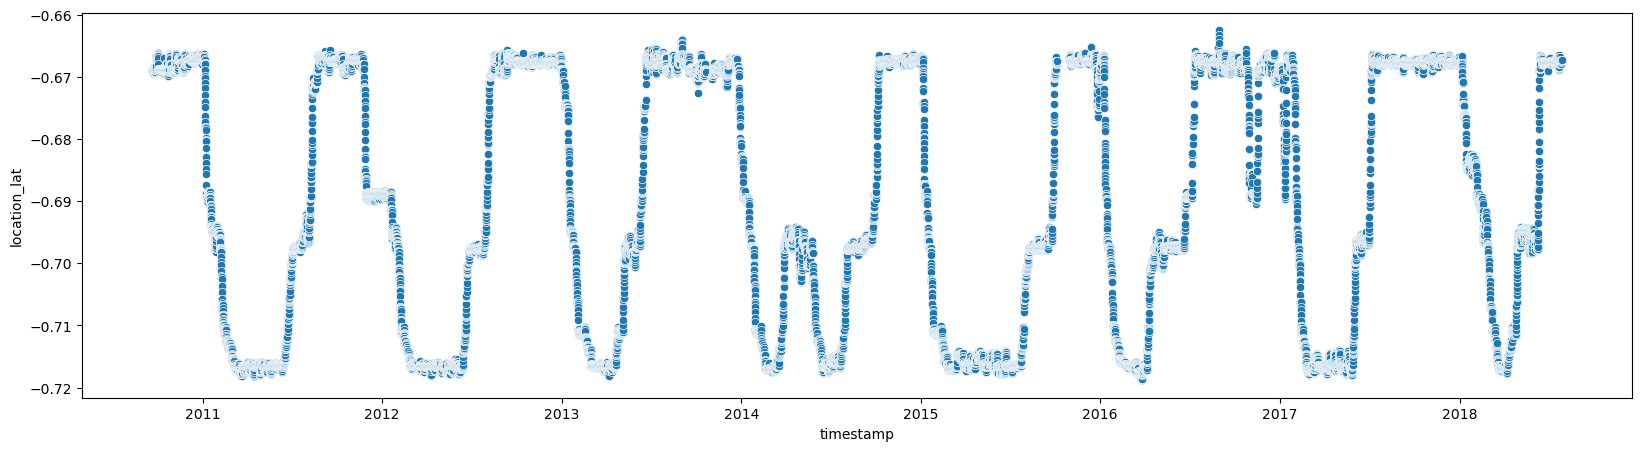

In [33]:
plot_invidual_lat_long("Steve Devine", "location_lat")

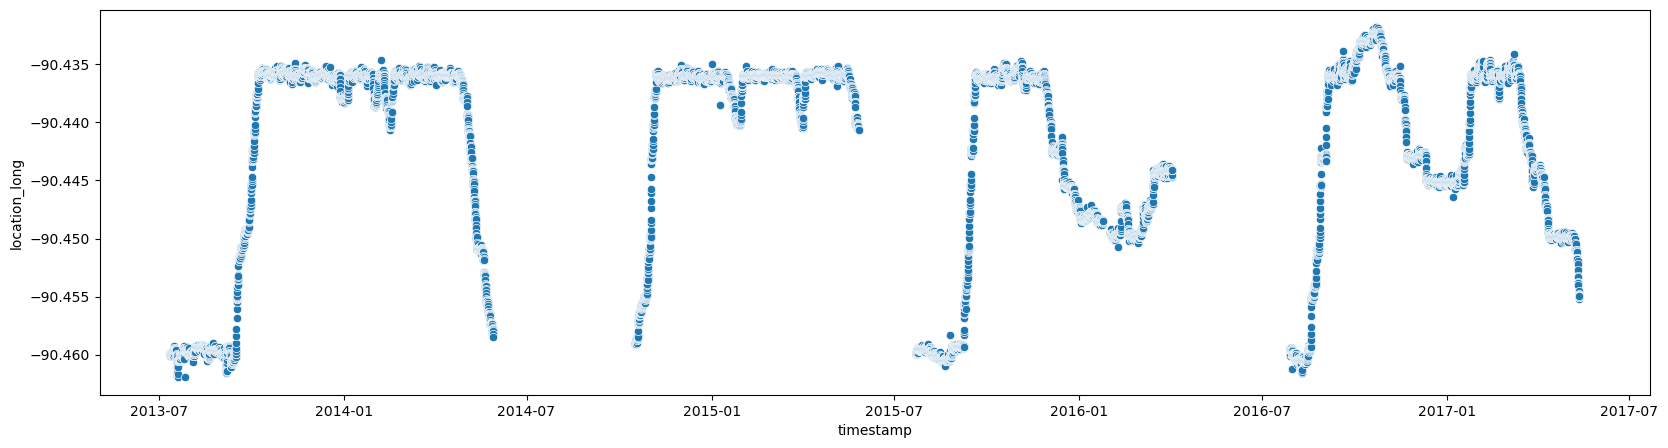

In [34]:
plot_invidual_lat_long("Chrissie", "location_long")

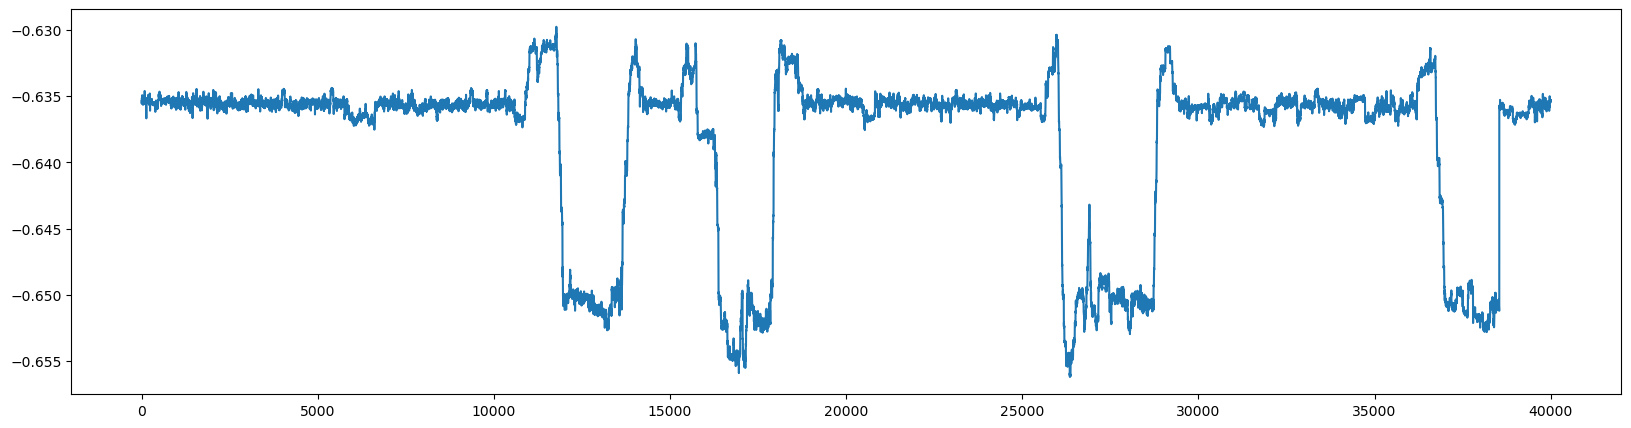

In [35]:
plt.figure(figsize = (20,5))
alison = tortoise[tortoise["individual_local_identifier"] == "Alison"]
plt.plot(alison.location_lat.values)

In [74]:
import skmob
from skmob.measures.individual import maximum_distance
tortoise_max_distance = maximum_distance(tortoise_trajectory)
tortoise_max_distance

100%|██████████| 96/96 [00:08<00:00, 11.89it/s]


,uid,maximum_distance
0,Alison,3.781776
1,Andrea,1.173420
2,Andres,0.711277
3,Anne,0.688293
4,Bill,1.053307
5,Birgit,0.368320
6,Carolina,1.518231
7,Charles,0.382068
8,Chica,0.560945
9,Chrissie,3.249870


In [78]:
from skmob.measures.individual import distance_straight_line, jump_lengths
distance_straight_line(alison_trajectory)

100%|██████████| 1/1 [00:00<00:00,  7.04it/s]


,uid,distance_straight_line
0,Alison,688.919058


In [95]:
jl = jump_lengths(alison_trajectory)
jl.jump_lengths.values[0][:100]

100%|██████████| 1/1 [00:00<00:00,  4.24it/s]


array([0.04375272, 0.00581471, 0.01779418, 0.01662345, 0.0037907 ,
       0.00950576, 0.03045961, 0.02785567, 0.005375  , 0.00819217,
       0.00675797, 0.04892049, 0.0079186 , 0.02212967, 0.07119279,
       0.00637234, 0.00582317, 0.00614284, 0.007851  , 0.00562757,
       0.00773561, 0.01153626, 0.01608056, 0.01576116, 0.02725424,
       0.00785945, 0.01982854, 0.00782146, 0.0061483 , 0.00865953,
       0.00142887, 0.00445947, 0.00228667, 0.03999809, 0.03592597,
       0.02166957, 0.0203882 , 0.01880529, 0.01658604, 0.05007076,
       0.01268326, 0.01046575, 0.0161297 , 0.02677552, 0.00913771,
       0.02617487, 0.00333632, 0.00619858, 0.00611221, 0.01171083,
       0.01902511, 0.00262371, 0.00658172, 0.00176811, 0.00704823,
       0.01344922, 0.00722332, 0.00455065, 0.00854419, 0.02217005,
       0.06426624, 0.00814821, 0.03427761, 0.03041867, 0.01348126,
       0.00603946, 0.00368777, 0.00741586, 0.00529267, 0.01684931,
       0.00265911, 0.00457059, 0.0019833 , 0.00552412, 0.00636

In [37]:
from skmob.measures.individual import number_of_locations
tortoise_num_locations = number_of_locations(tortoise_trajectory)
tortoise_num_locations

100%|██████████| 96/96 [00:20<00:00,  4.58it/s]


,uid,number_of_locations
0,Alison,40002
1,Andrea,1519
2,Andres,3739
3,Anne,41109
4,Bill,1814
5,Birgit,28311
6,Carolina,45354
7,Charles,9178
8,Chica,1754
9,Chrissie,25349


<Axes: >

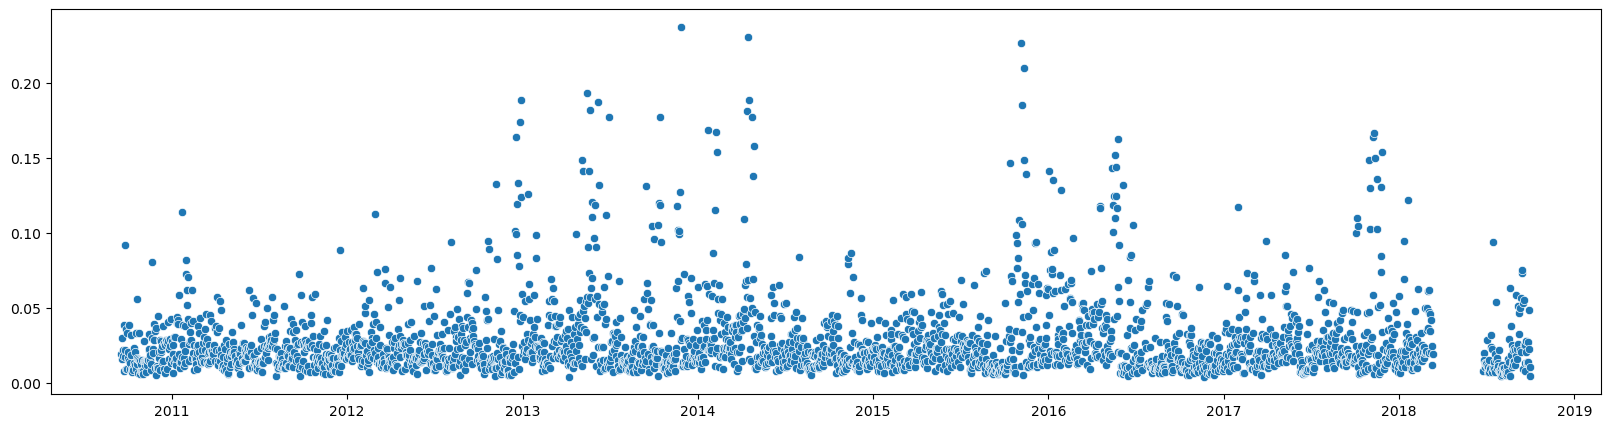

In [38]:
from skmob.measures.individual import radius_of_gyration
alison_rog = []
date_list = []
for date in alison.date.unique():
    date_list.append(date)
    alison_rog.append(radius_of_gyration(alison_trajectory[alison_trajectory["date"] == date], show_progress=False)["radius_of_gyration"])
plt.figure(figsize = (20,5))
sns.scatterplot(x=date_list, y=np.array(alison_rog).ravel())

<Axes: xlabel='timestamp_local', ylabel='location_long'>

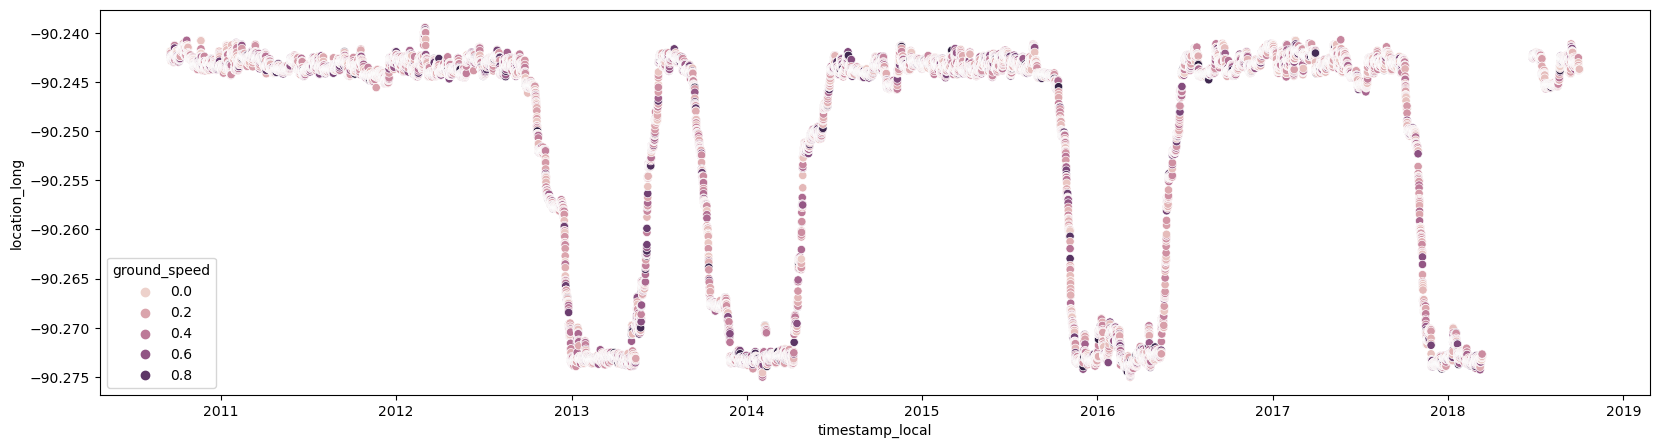

In [39]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <1") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="location_long", hue="ground_speed")

<Axes: xlabel='timestamp_local', ylabel='ground_speed'>

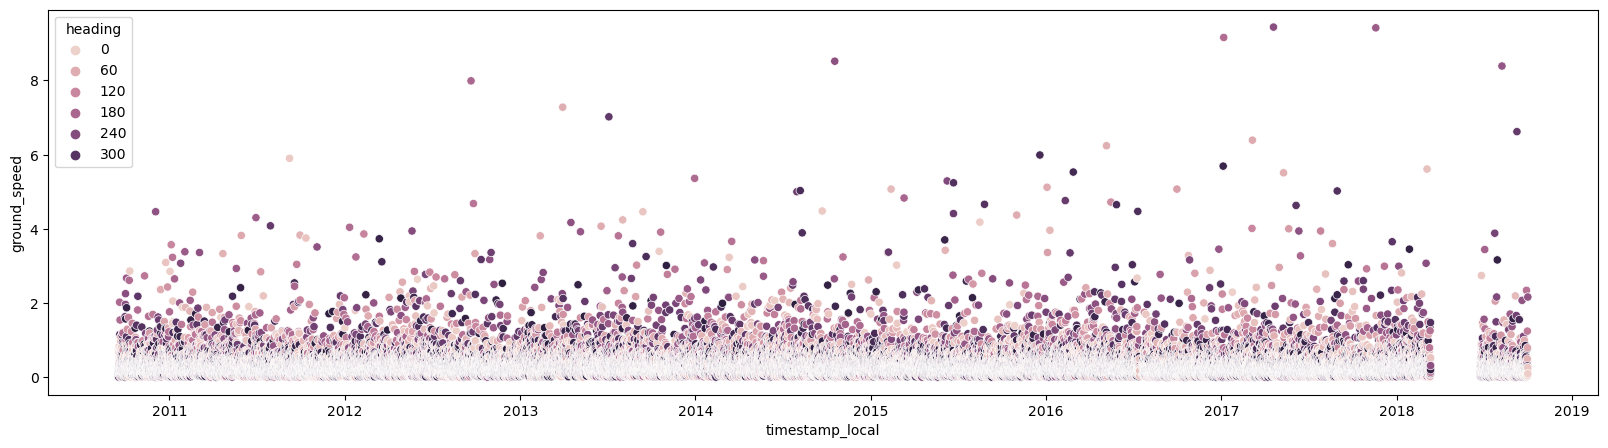

In [40]:
plt.figure(figsize = (20,5))
temp_df = tortoise.query("individual_local_identifier == 'Alison' and ground_speed < 10") # ground_speed unit is meters per second
sns.scatterplot(temp_df, x = "timestamp_local", y="ground_speed", hue="heading")

<Axes: xlabel='timestamp_local', ylabel='ground_speed'>

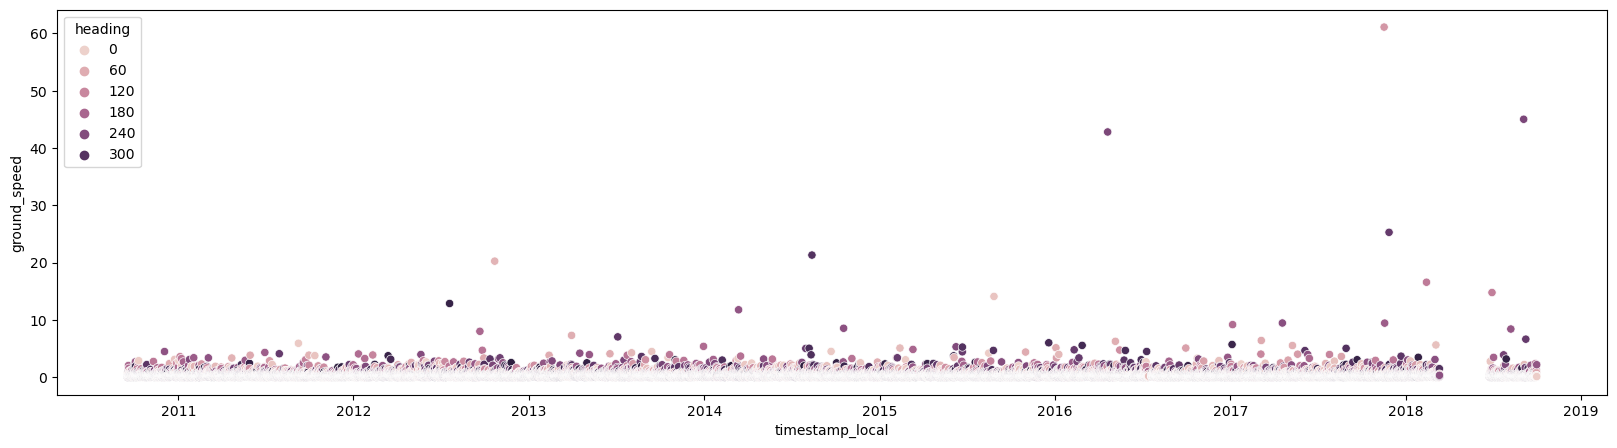

In [41]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison'") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="ground_speed", hue="heading")